In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import loader_XA_to_NA
import importlib
importlib.reload(loader_XA_to_NA)
import tifffile

In [32]:
xray_slices = range(500,900)
neutron_slices = range(1100,1300)
output_volume = [[1100,1300],[None], [None]]
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset='tv', xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Resampling the transformation
Resampling moving image


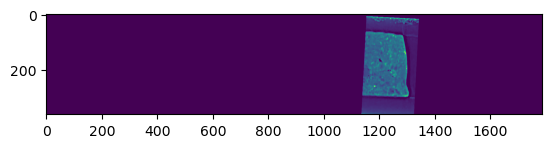

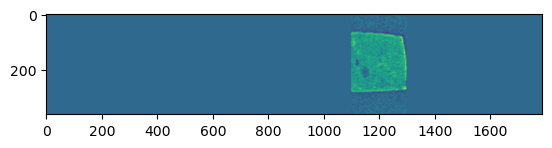

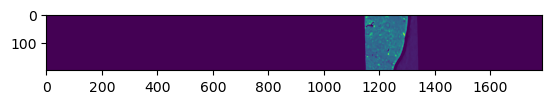

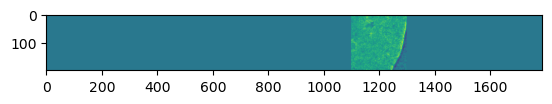

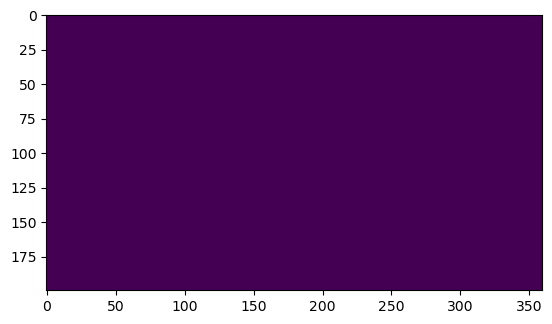

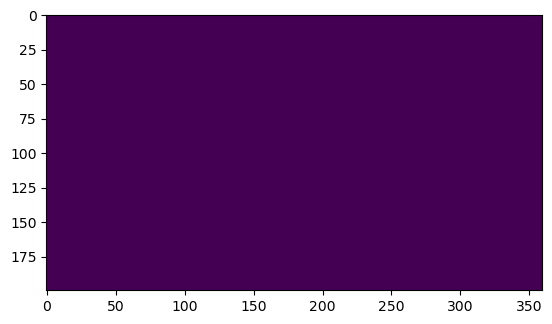

In [30]:
fixed = reg.as_array(reg.fixed)
moving = reg.as_array(reg.moving)
plt.imshow(moving[100])
plt.show()
plt.imshow(fixed[100])
plt.show()
plt.imshow(moving[:,100])
plt.show()
plt.imshow(fixed[:,100])
plt.show()
plt.imshow(moving[:,:,200])
plt.show()
plt.imshow(fixed[:,:,200])
plt.show()

In [ ]:
nz, ny, nx = np.shape(moving)
from cil.framework import ImageGeometry, ImageData
from cil.optimisation.operators import GradientOperator
ig = ImageGeometry(voxel_num_x=nx, voxel_num_y=ny, voxel_num_z=nz)
im_subset_ID = ImageData(moving, geometry=ig)
def xi_vector_field(image,eta):
    G = GradientOperator(ig)
    numerator = G.direct(image)
    denominator = np.sqrt(eta**2 + numerator.get_item(0)**2 + numerator.get_item(1)**2)
    xi = numerator/denominator

    return (xi.get_item(0)**2 + xi.get_item(1)**2).sqrt()
